# Deadtime estimates (channel threshold)

Project 2D (channels, windows) into 1D using `x = channels * windows`, then fit `deadtime = m*x + b`.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2

sns.set_context('talk')

ROOT = Path.cwd().resolve().parent
EST_PATH = ROOT / 'data' / 'estimated_deadtime_10hz-12-22-25_full_channels.json'

with EST_PATH.open() as fh:
    estimates = json.load(fh)
est_df = pd.DataFrame(estimates)

print('Rows:', len(est_df))
print('Pulse rates:', sorted(est_df['pulse_rate_hz'].dropna().unique()))
print('Pulse counts:', sorted(est_df['num_pulses'].dropna().unique()))


Rows: 91
Pulse rates: [np.float64(10.0)]
Pulse counts: [np.int64(2)]


## Linear fit on projected axis


m = 1.338150 us per (channels*windows)
b = 9.362964 us
chi2 = 1217719.78, dof = 89, chi2/dof = 13682.24, p = 0


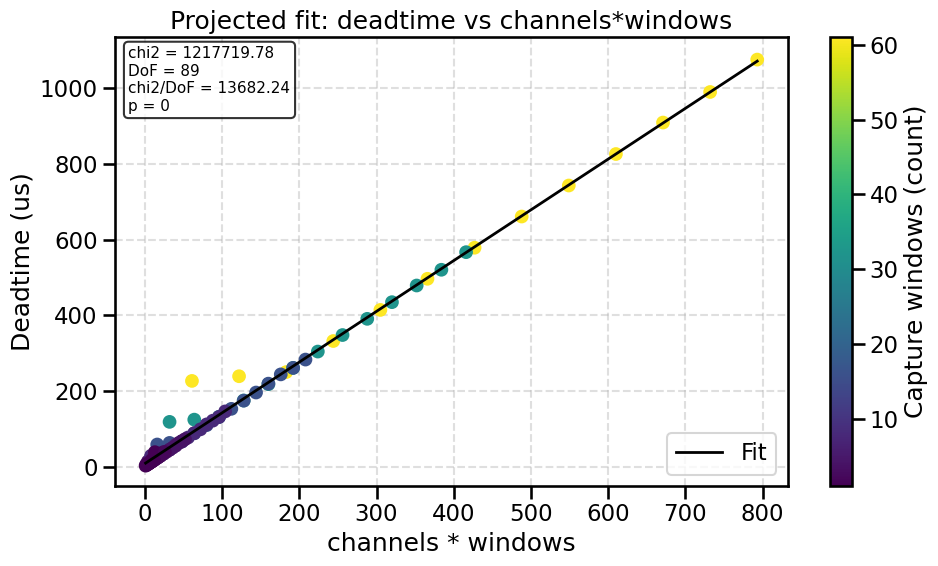

In [2]:
df = est_df.copy()
df = df.dropna(subset=['channel_count', 'windows', 'min_all_pulses_response_us'])
df = df[df['all_pulses_observed'] == True]

df['x'] = df['channel_count'] * df['windows']
df['y'] = df['min_all_pulses_response_us']
df['yerr'] = df['min_all_pulses_response_us'] - df['min_all_pulses_lower_bound_us']
df = df.dropna(subset=['yerr'])
df = df[df['yerr'] > 0]

x = df['x'].to_numpy(dtype=float)
y = df['y'].to_numpy(dtype=float)
yerr = df['yerr'].to_numpy(dtype=float)

m, b = np.polyfit(x, y, 1)
y_fit = m * x + b

chi2_val = np.sum(((y - y_fit) / yerr) ** 2)
dof = len(y) - 2
p_val = chi2.sf(chi2_val, dof) if dof > 0 else float('nan')

print(f'm = {m:.6f} us per (channels*windows)')
print(f'b = {b:.6f} us')
print(f'chi2 = {chi2_val:.2f}, dof = {dof}, chi2/dof = {chi2_val / dof:.2f}, p = {p_val:.3g}')

plt.figure(figsize=(10, 6))
ax = plt.gca()
stats_text = f'chi2 = {chi2_val:.2f}\nDoF = {dof}\nchi2/DoF = {chi2_val / dof:.2f}\np = {p_val:.3g}'
ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, ha='left', va='top', fontsize=11, bbox={'boxstyle': 'round,pad=0.3', 'facecolor': 'white', 'alpha': 0.8})

plt.errorbar(x, y, yerr=yerr, fmt='none', ecolor='gray', alpha=0.5, zorder=1)
sc = plt.scatter(x, y, c=df['windows'], cmap='viridis', s=70, zorder=2)
x_line = np.linspace(x.min(), x.max(), 200)
plt.plot(x_line, m * x_line + b, color='black', linewidth=2, label='Fit')
cbar = plt.colorbar(sc)
cbar.set_label('Capture windows (count)')
plt.title('Projected fit: deadtime vs channels*windows')
plt.xlabel('channels * windows')
plt.ylabel('Deadtime (us)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


## Per-pulse fit (optional)


Pulses=2: m=1.338150, b=9.362964, chi2=1217719.78, dof=89, p=0


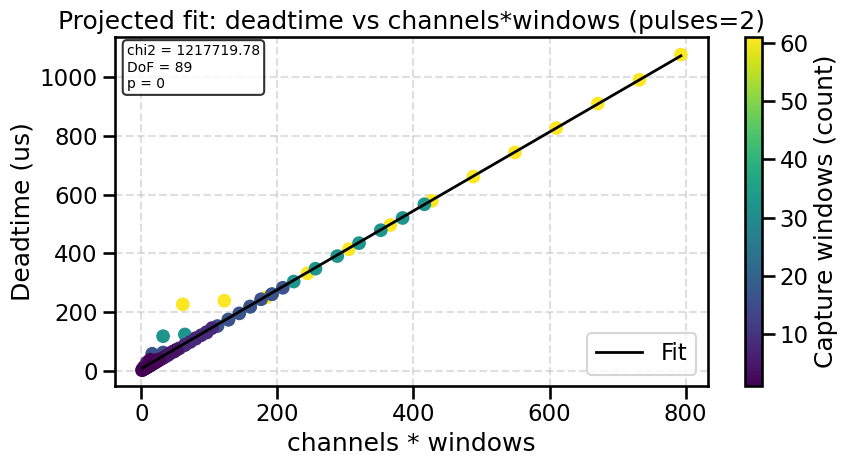

In [3]:
for pulse_count in sorted(df['num_pulses'].dropna().unique()):
    sub = df[df['num_pulses'] == pulse_count]
    if len(sub) < 3:
        continue
    x = sub['x'].to_numpy(dtype=float)
    y = sub['y'].to_numpy(dtype=float)
    yerr = sub['yerr'].to_numpy(dtype=float)
    m, b = np.polyfit(x, y, 1)
    y_fit = m * x + b
    chi2_val = np.sum(((y - y_fit) / yerr) ** 2)
    dof = len(y) - 2
    p_val = chi2.sf(chi2_val, dof) if dof > 0 else float('nan')
    print(f'Pulses={int(pulse_count)}: m={m:.6f}, b={b:.6f}, chi2={chi2_val:.2f}, dof={dof}, p={p_val:.3g}')
    plt.figure(figsize=(9, 5))
    ax = plt.gca()
    stats_text = f'chi2 = {chi2_val:.2f}\nDoF = {dof}\np = {p_val:.3g}'
    ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, ha='left', va='top', fontsize=10, bbox={'boxstyle': 'round,pad=0.3', 'facecolor': 'white', 'alpha': 0.8})
    plt.errorbar(x, y, yerr=yerr, fmt='none', ecolor='gray', alpha=0.5, zorder=1)
    sc = plt.scatter(x, y, c=sub['windows'], cmap='viridis', s=70, zorder=2)
    x_line = np.linspace(x.min(), x.max(), 200)
    plt.plot(x_line, m * x_line + b, color='black', linewidth=2, label='Fit')
    cbar = plt.colorbar(sc)
    cbar.set_label('Capture windows (count)')
    plt.title(f'Projected fit: deadtime vs channels*windows (pulses={int(pulse_count)})')
    plt.xlabel('channels * windows')
    plt.ylabel('Deadtime (us)')
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()
